In [1]:
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import numpy as np
import imageio.v3 as iio
import os
import xml.etree.ElementTree as ET # Import for XML parsing
from math import ceil # For calculating canvas dimensions
from skimage.transform import resize # For potential tile resizing
import re # Import for regular expressions

# --- Function to parse stitching metadata ---
def parse_stitching_metadata(round_name, data_path):
    """
    Parses the Imaris stitching metadata from XML and TXT files for a given round.

    Args:
        round_name (str): The base name of the round (e.g., "Round0_30_300_1").
        data_path (str): The path to the directory containing the metadata files.

    Returns:
        dict: A dictionary containing:
            - 'tile_info': List of dicts, each with 'full_ims_path', 'min_x_um', 'min_y_um', 'max_x_um', 'max_y_um'.
            - 'tile_pixel_width': Width of a single tile in pixels.
            - 'tile_pixel_height': Height of a single tile in pixels.
            - 'effective_pixel_width_um': Effective physical width of one pixel in micrometers (derived).
            - 'effective_pixel_height_um': Effective physical height of one pixel in micrometers (derived).
    """
    metadata = {
        'tile_info': [],
        'tile_pixel_width': None,
        'tile_pixel_height': None,
        'effective_pixel_width_um': None, # Derived from physical extent and pixel count
        'effective_pixel_height_um': None # Derived from physical extent and pixel count
    }

    # --- Parse _FusionStitcher_pair.xml for ImageExtends ---
    xml_filepath = os.path.join(data_path, f"{round_name}_FusionStitcher_pair.xml")
    print(f"Attempting to parse XML: {xml_filepath}")
    try:
        tree = ET.parse(xml_filepath)
        root = tree.getroot()
        for img_extend in root.findall(".//ImageExtends"):
            xml_image_path = img_extend.get("Image")
            base_filename = os.path.basename(xml_image_path)
            correct_full_ims_path = os.path.join(data_path, base_filename)

            min_coords_str = img_extend.get("ExtendMin").split()
            max_coords_str = img_extend.get("ExtendMax").split()

            min_x_um = float(min_coords_str[0])
            min_y_um = float(min_coords_str[1])
            max_x_um = float(max_coords_str[0])
            max_y_um = float(max_coords_str[1])

            metadata['tile_info'].append({
                'full_ims_path': correct_full_ims_path,
                'min_x_um': min_x_um,
                'min_y_um': min_y_um,
                'max_x_um': max_x_um,
                'max_y_um': max_y_um
            })
        print(f"XML parsing successful. Found {len(metadata['tile_info'])} tiles.")
    except FileNotFoundError:
        print(f"ERROR: XML file not found at {xml_filepath}")
        return None
    except Exception as e:
        print(f"ERROR parsing {xml_filepath}: {e}")
        return None

    # --- Parse _metadata.txt for pixel dimensions ---
    txt_filepath = os.path.join(data_path, f"{round_name}_metadata.txt")
    print(f"Attempting to parse TXT: {txt_filepath}")
    try:
        with open(txt_filepath, 'r') as f:
            for line in f:
                stripped_line = line.strip() # Strip leading/trailing whitespace

                if stripped_line.startswith("Width="):
                    metadata['tile_pixel_width'] = int(stripped_line.split('=')[1].strip())
                    print(f"Found tile_pixel_width: {metadata['tile_pixel_width']}")
                elif stripped_line.startswith("Height="):
                    metadata['tile_pixel_height'] = int(stripped_line.split('=')[1].strip())
                    print(f"Found tile_pixel_height: {metadata['tile_pixel_height']}")
                # We ignore the "Pixel Width (µm)" from metadata.txt as it's the raw sensor pixel size
                # and not the effective pixel size after magnification.
        print("TXT parsing complete.")
    except FileNotFoundError:
        print(f"ERROR: TXT file not found at {txt_filepath}")
        return None
    except Exception as e:
        print(f"ERROR parsing {txt_filepath}: {e}")
        return None

    # --- Derive effective pixel size from the first tile's physical extent and pixel dimensions ---
    if metadata['tile_info'] and metadata['tile_pixel_width'] and metadata['tile_pixel_height']:
        first_tile = metadata['tile_info'][0]
        physical_width_first_tile = first_tile['max_x_um'] - first_tile['min_x_um']
        physical_height_first_tile = first_tile['max_y_um'] - first_tile['min_y_um']

        metadata['effective_pixel_width_um'] = physical_width_first_tile / metadata['tile_pixel_width']
        metadata['effective_pixel_height_um'] = physical_height_first_tile / metadata['tile_pixel_height']
        print(f"Derived effective_pixel_width_um: {metadata['effective_pixel_width_um']:.4f}")
        print(f"Derived effective_pixel_height_um: {metadata['effective_pixel_height_um']:.4f}")
    else:
        print("ERROR: Cannot derive effective pixel size. Missing tile info or pixel dimensions.")
        return None


    # Basic validation
    if not all([metadata['tile_info'], metadata['tile_pixel_width'],
                metadata['tile_pixel_height'], metadata['effective_pixel_width_um'],
                metadata['effective_pixel_height_um']]):
        print("ERROR: Missing critical metadata after parsing. One or more values are None.")
        return None

    return metadata


# --- Function to stitch Max Z Projections ---
# --- Function to stitch Max Z Projections ---
def stitch_max_z_projection(stitching_metadata, output_filename, round_name,
                            current_round_num, total_rounds, # New parameters
                            channel_index=0, time_index=0, scene_index=0):
    """
    Calculates Max Z Projection for each tile and stitches them into a single image.

    Args:
        stitching_metadata (dict): Dictionary containing parsed metadata from parse_stitching_metadata.
        output_filename (str): Full path to save the stitched TIFF image.
        round_name (str): The base name of the round (e.g., "Round0_30_300_1"). Used for plot title.
        current_round_num (int): The 1-based index of the current round being processed.
        total_rounds (int): The total number of rounds to be processed.
        channel_index (int): The channel index to use for Max Z Projection (default is 0).
        time_index (int): The time point index to use (default is 0).
        scene_index (int): The scene index to use (default is 0).

    Returns:
        np.ndarray: The stitched image array, or None if an error occurred.
    """
    if not stitching_metadata:
        print("Error: No stitching metadata provided.")
        return None

    tile_info = stitching_metadata['tile_info']
    tile_pixel_width = stitching_metadata['tile_pixel_width']
    tile_pixel_height = stitching_metadata['tile_pixel_height']
    # Use the derived effective pixel sizes
    pixel_width_um = stitching_metadata['effective_pixel_width_um']
    pixel_height_um = stitching_metadata['effective_pixel_height_um']

    # 1. Determine overall physical bounds of the stitched image
    min_x_um_global = float('inf')
    min_y_um_global = float('inf')
    max_x_um_global = float('-inf')
    max_y_um_global = float('-inf')

    for tile in tile_info:
        min_x_um_global = min(min_x_um_global, tile['min_x_um'])
        min_y_um_global = min(min_y_um_global, tile['min_y_um'])
        max_x_um_global = max(max_x_um_global, tile['max_x_um'])
        max_y_um_global = max(max_y_um_global, tile['max_y_um'])

    print(f"\nGlobal physical bounds (µm):")
    print(f"  X: [{min_x_um_global:.2f}, {max_x_um_global:.2f}]")
    print(f"  Y: [{min_y_um_global:.2f}, {max_y_um_global:.2f}]")

    # 2. Calculate overall pixel dimensions for the canvas
    overall_width_um = max_x_um_global - min_x_um_global
    overall_height_um = max_y_um_global - min_y_um_global

    canvas_width_pixels = int(ceil(overall_width_um / pixel_width_um))
    canvas_height_pixels = int(ceil(overall_height_um / pixel_height_um))

    print(f"Calculated canvas dimensions: {canvas_width_pixels}x{canvas_height_pixels} pixels")

    # Initialize two canvases for average intensity projection:
    # one for summing intensities, one for counting contributions
    stitched_image_sum = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.float32) # Use float for sum
    stitched_image_count = np.zeros((canvas_height_pixels, canvas_width_pixels), dtype=np.uint8) # Count contributions

    print(f"Initialized stitched image sum canvas of shape {stitched_image_sum.shape} with dtype {stitched_image_sum.dtype}")
    print(f"Initialized stitched image count canvas of shape {stitched_image_count.shape} with dtype {stitched_image_count.dtype}")

    # 3. Process and stitch each tile
    total_tiles = len(tile_info)
    for i, tile in enumerate(tile_info):
        # Updated print statement
        print(f"Processing Round {current_round_num} of {total_rounds}; tile {i+1}/{total_tiles}: {os.path.basename(tile['full_ims_path'])}")
        try:
            # Load the .ims file
            img = AICSImage(tile['full_ims_path'])

            # Get image data in ZYX order for the specified channel, time, and scene
            image_data_zyx = img.get_image_data("ZYX", T=time_index, S=scene_index, C=channel_index)

            # Perform Max Z Projection
            if image_data_zyx.shape[0] > 1:
                projected_tile = np.max(image_data_zyx, axis=0)
            else:
                projected_tile = image_data_zyx[0, :, :]

            # Convert tile physical coordinates to canvas pixel coordinates
            # The offset is relative to the global minimum physical coordinate
            tile_offset_x_um = tile['min_x_um'] - min_x_um_global
            tile_offset_y_um = tile['min_y_um'] - min_y_um_global

            # Convert micrometers to pixels, rounding to the nearest integer
            tile_start_x_px = int(round(tile_offset_x_um / pixel_width_um))
            tile_start_y_px = int(round(tile_offset_y_um / pixel_height_um))

            # Calculate end pixel coordinates for the tile
            tile_end_x_px = tile_start_x_px + tile_pixel_width
            tile_end_y_px = tile_start_y_px + tile_pixel_height

            # Ensure the projected tile matches the expected dimensions from metadata
            if projected_tile.shape[0] != tile_pixel_height or projected_tile.shape[1] != tile_pixel_width:
                print(f"Warning: Tile {os.path.basename(tile['full_ims_path'])} has dimensions {projected_tile.shape} but metadata expects {tile_pixel_height}x{tile_pixel_width}. Resizing...")
                projected_tile = resize(projected_tile, (tile_pixel_height, tile_pixel_width), anti_aliasing=True, preserve_range=True).astype(stitched_image_sum.dtype) # Cast to float for sum


            # Check if the tile would extend beyond the canvas boundaries
            if tile_end_y_px > stitched_image_sum.shape[0] or tile_end_x_px > stitched_image_sum.shape[1]:
                print(f"Warning: Tile {os.path.basename(tile['full_ims_path'])} extends beyond canvas boundaries. Cropping tile.")
                # Crop the tile to fit the canvas
                crop_height = max(0, stitched_image_sum.shape[0] - tile_start_y_px)
                crop_width = max(0, stitched_image_sum.shape[1] - tile_start_x_px)
                projected_tile = projected_tile[:crop_height, :crop_width]
                tile_end_y_px = tile_start_y_px + projected_tile.shape[0]
                tile_end_x_px = tile_start_x_px + projected_tile.shape[1]

            # Add tile intensity to the sum canvas
            stitched_image_sum[tile_start_y_px:tile_end_y_px, tile_start_x_px:tile_end_x_px] += projected_tile

            # Increment count for pixels covered by this tile
            # Only increment where the tile actually has data (i.e., not padding if any)
            stitched_image_count[tile_start_y_px:tile_end_y_px, tile_start_x_px:tile_end_x_px] += 1


        except Exception as e:
            print(f"Error processing tile {os.path.basename(tile['full_ims_path'])}: {e}")
            continue

    # 4. Calculate the final averaged image
    # Avoid division by zero where no tiles contributed
    stitched_image = np.divide(stitched_image_sum, stitched_image_count,
                                out=np.zeros_like(stitched_image_sum),
                                where=stitched_image_count != 0)

    # Convert back to original dtype (e.g., uint16) and clip values
    # Assuming original images are uint16, max value is 65535
    stitched_image = np.clip(stitched_image, 0, 65535).astype(np.uint16)


    # 5. Save stitched image
    try:
        iio.imwrite(output_filename, stitched_image)
        print(f"\nSuccessfully saved stitched image to '{output_filename}'")
    except Exception as e:
        print(f"Error saving stitched image to '{output_filename}': {e}")
        return None

    # 6. Display (optional)
    plt.figure(figsize=(12, 12))
    plt.imshow(stitched_image, cmap='gray')
    plt.title(f"Stitched Average Z Projection for {round_name}") # Updated title
    plt.colorbar(label='Intensity')
    plt.axis('off')
    plt.show()

    return stitched_image

print('All functions go!')

All functions go!


Ensured output directory exists: E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_avgIntAtOverlap
Found 15 unique rounds to process: Round0_30_300, Round0_30_300_1, Round10_CD45_A27_30_300, Round11_SMA_A25_30_300, Round12_panCK_A38_30_300, Round13_CD3_A8_30_300, Round1_CD8_A19_30_300, Round2_CD3_A8_30_300, Round3_CD4_A39_30_300, Round4_CD20_A3_30_300, Round5_Tom20_A20_30_300, Round6_CD63_A10_30_300, Round7_CD19_A36_30_300, Round8_Vimentin_A5_30_300, Round9_Ki67_A15_30_300

--- Processing Round 1 of 15: Round0_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixe

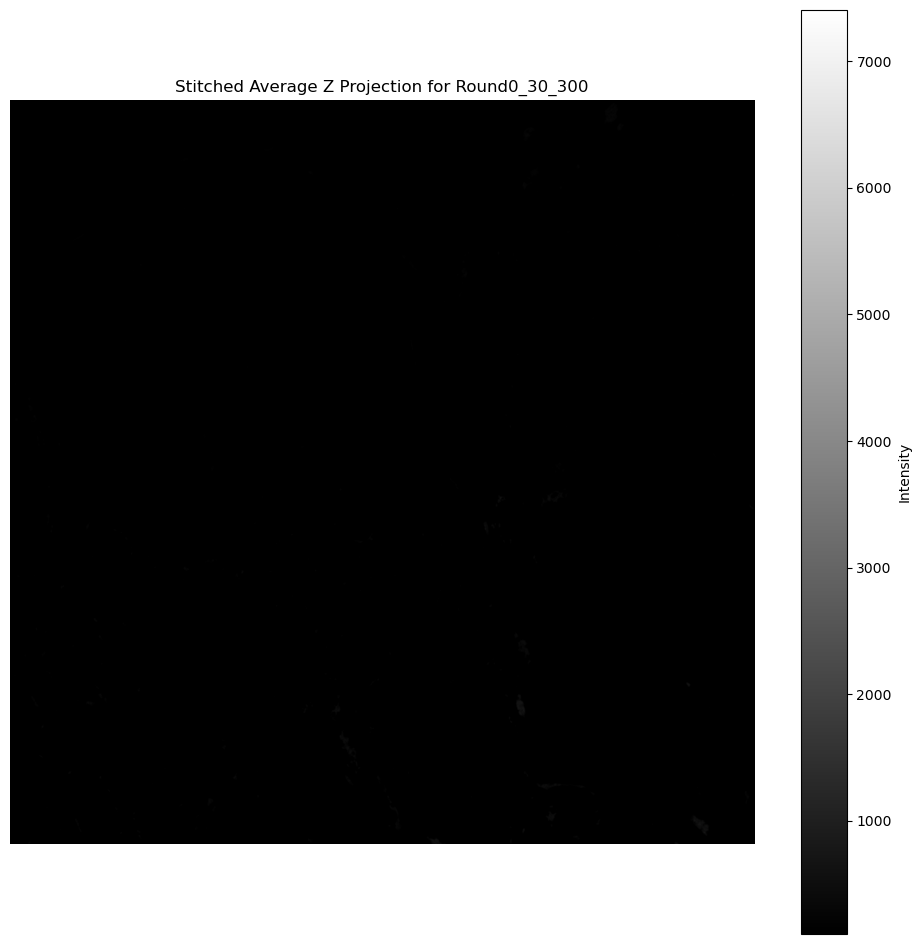

Stitching process completed for Round0_30_300.
--- Finished Round 1 of 15: Round0_30_300 ---


--- Processing Round 2 of 15: Round0_30_300_1 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_1_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round0_30_300_1_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape (8123, 8131) with dtype uint8
Proce

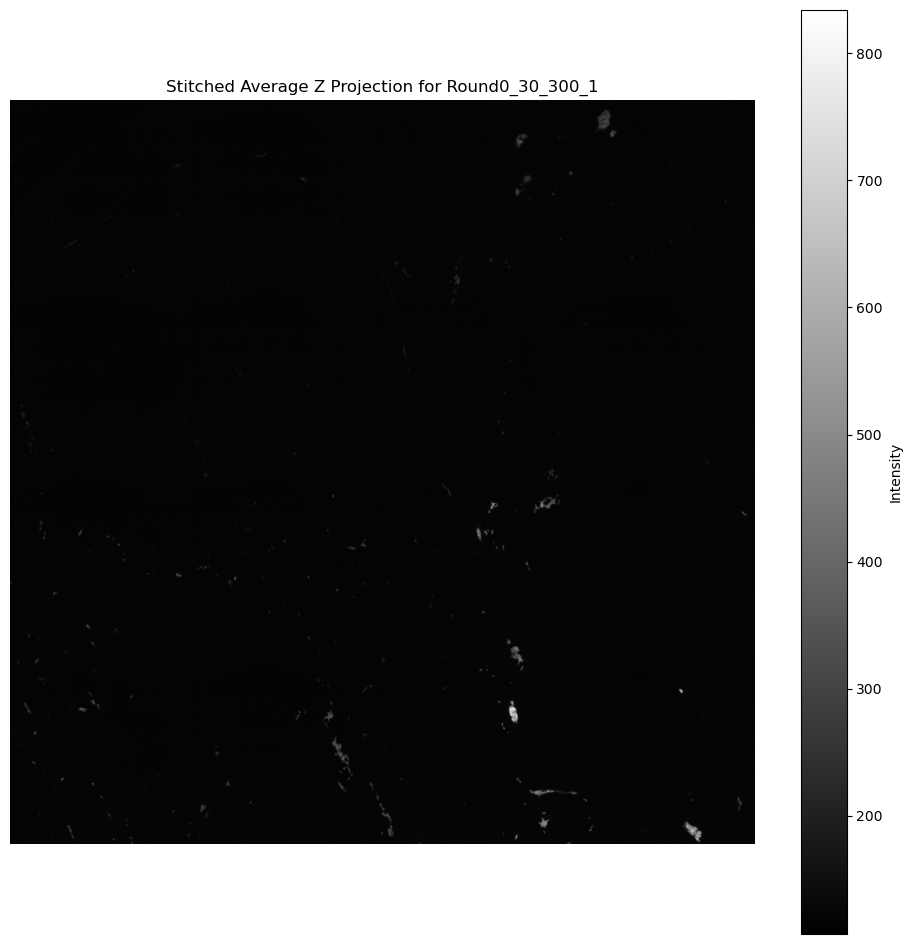

Stitching process completed for Round0_30_300_1.
--- Finished Round 2 of 15: Round0_30_300_1 ---


--- Processing Round 3 of 15: Round10_CD45_A27_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round10_CD45_A27_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round10_CD45_A27_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape (8123, 

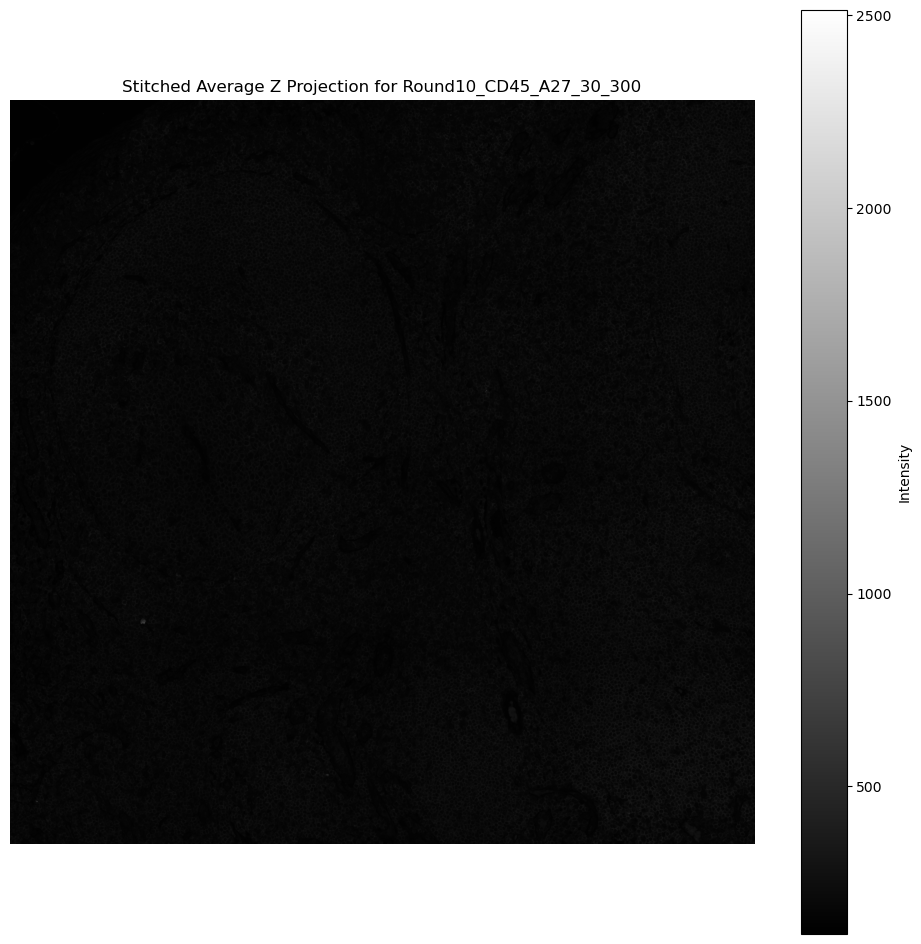

Stitching process completed for Round10_CD45_A27_30_300.
--- Finished Round 3 of 15: Round10_CD45_A27_30_300 ---


--- Processing Round 4 of 15: Round11_SMA_A25_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round11_SMA_A25_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round11_SMA_A25_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of 

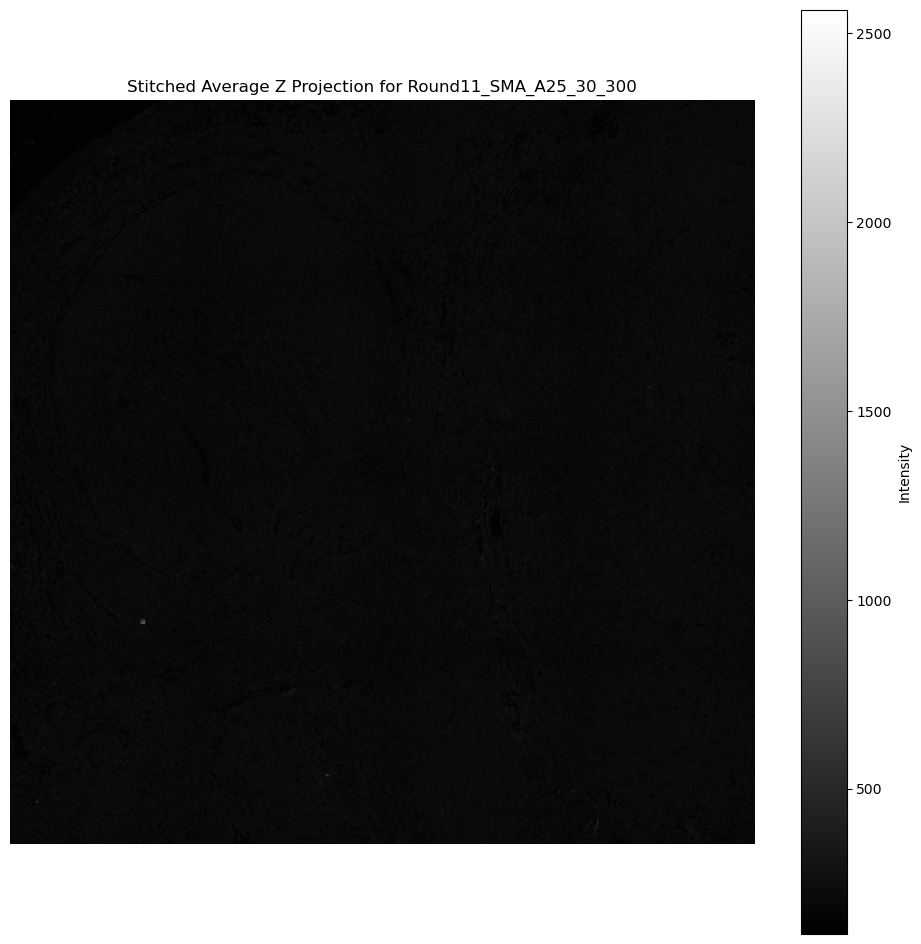

Stitching process completed for Round11_SMA_A25_30_300.
--- Finished Round 4 of 15: Round11_SMA_A25_30_300 ---


--- Processing Round 5 of 15: Round12_panCK_A38_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round12_panCK_A38_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round12_panCK_A38_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas

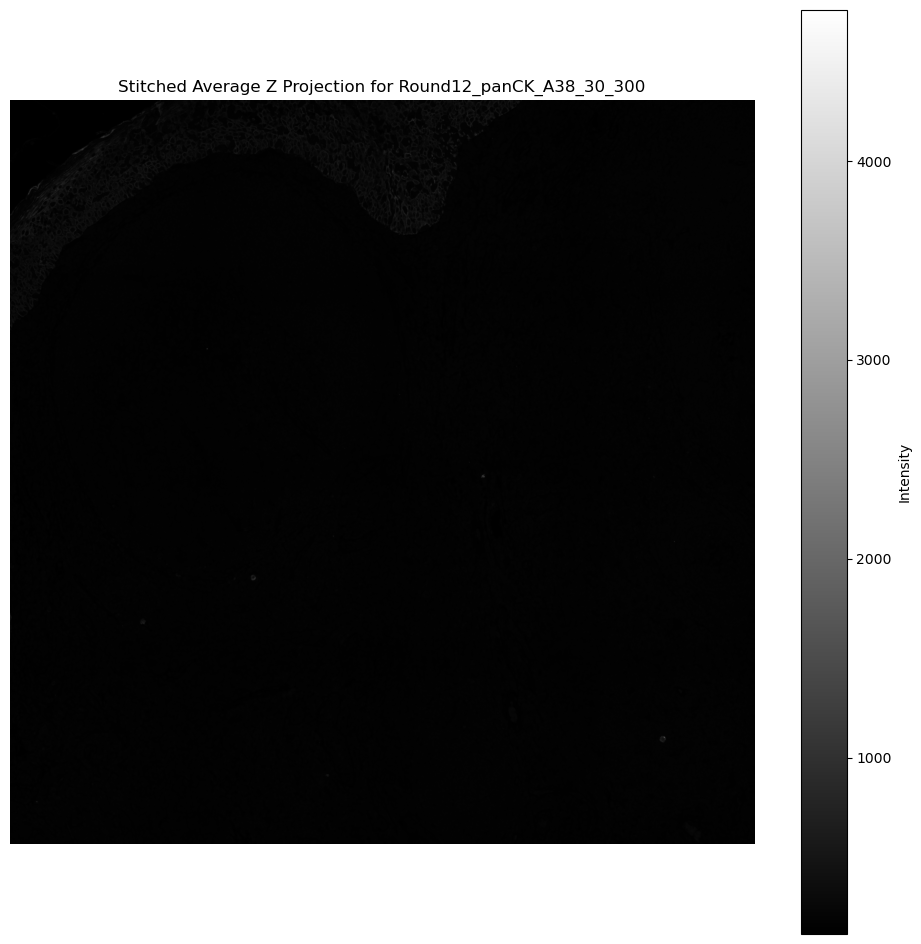

Stitching process completed for Round12_panCK_A38_30_300.
--- Finished Round 5 of 15: Round12_panCK_A38_30_300 ---


--- Processing Round 6 of 15: Round13_CD3_A8_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round13_CD3_A8_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round13_CD3_A8_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of s

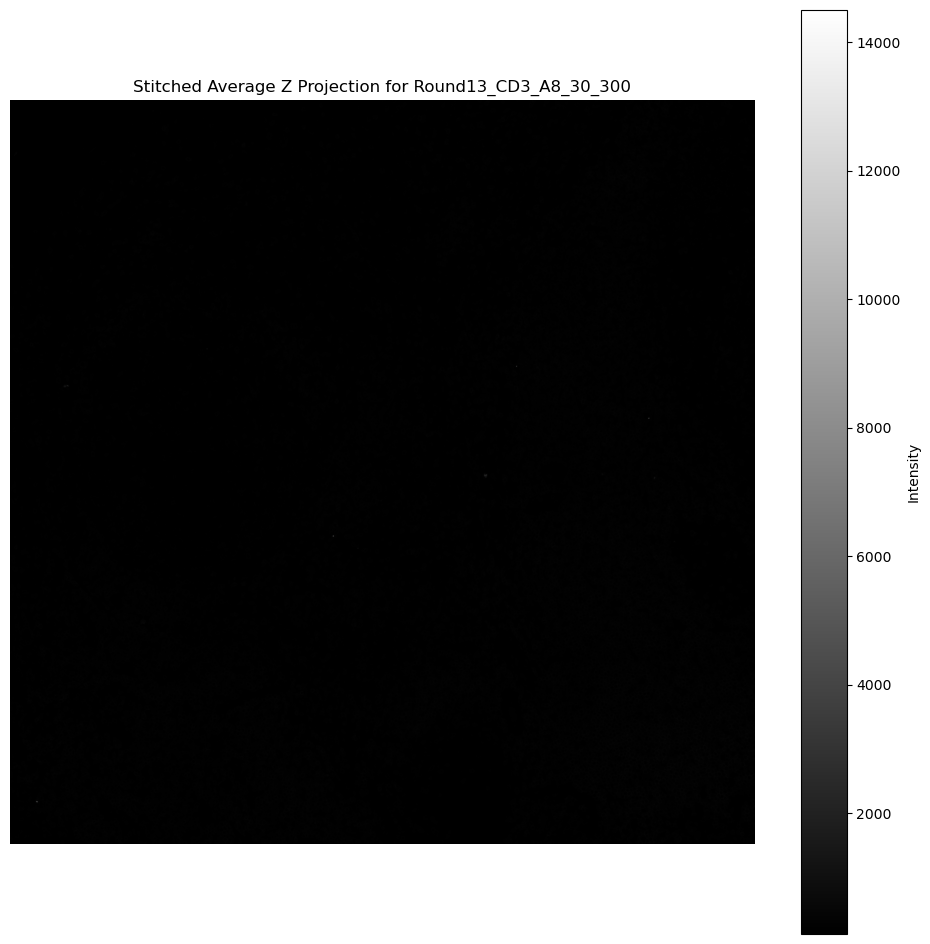

Stitching process completed for Round13_CD3_A8_30_300.
--- Finished Round 6 of 15: Round13_CD3_A8_30_300 ---


--- Processing Round 7 of 15: Round1_CD8_A19_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round1_CD8_A19_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round1_CD8_A19_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape (

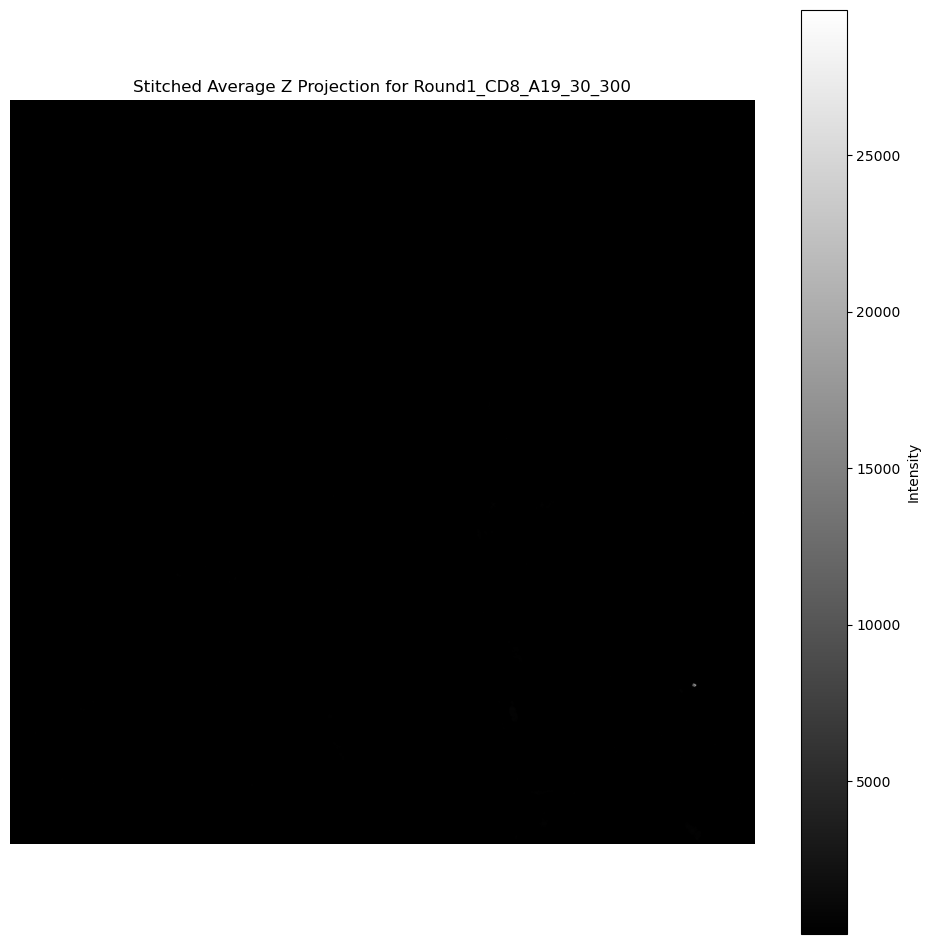

Stitching process completed for Round1_CD8_A19_30_300.
--- Finished Round 7 of 15: Round1_CD8_A19_30_300 ---


--- Processing Round 8 of 15: Round2_CD3_A8_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round2_CD3_A8_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round2_CD3_A8_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape (812

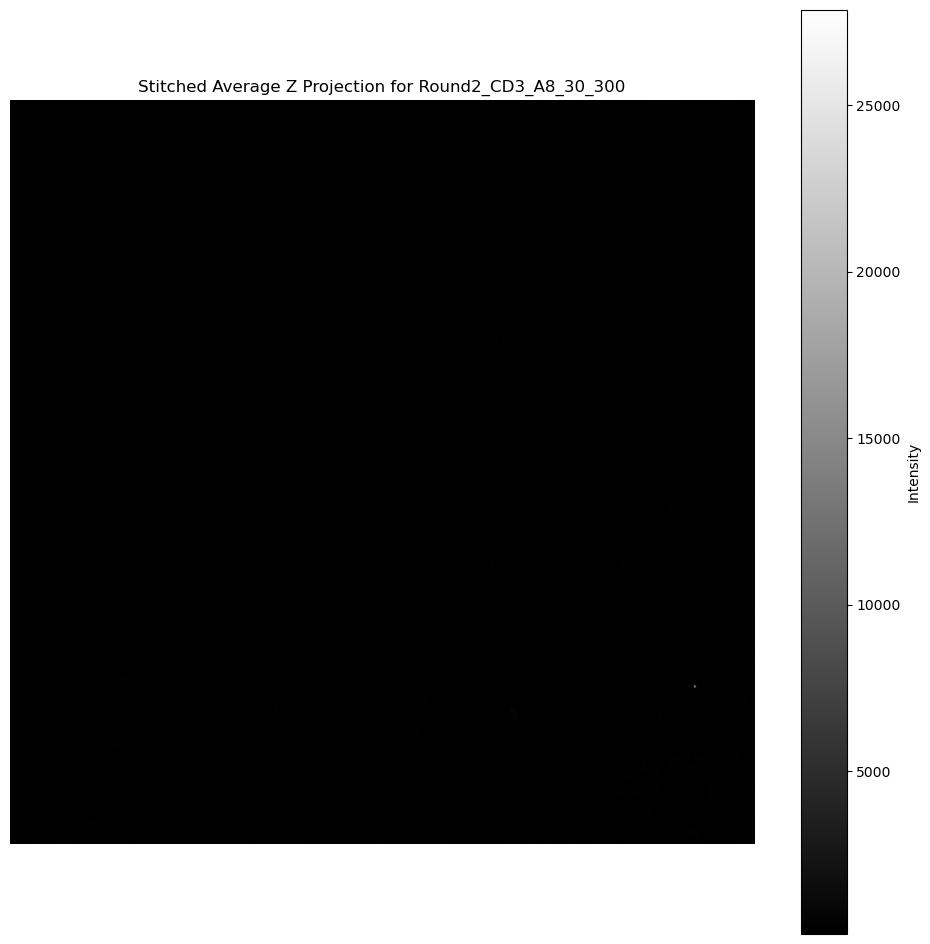

Stitching process completed for Round2_CD3_A8_30_300.
--- Finished Round 8 of 15: Round2_CD3_A8_30_300 ---


--- Processing Round 9 of 15: Round3_CD4_A39_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round3_CD4_A39_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round3_CD4_A39_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape (81

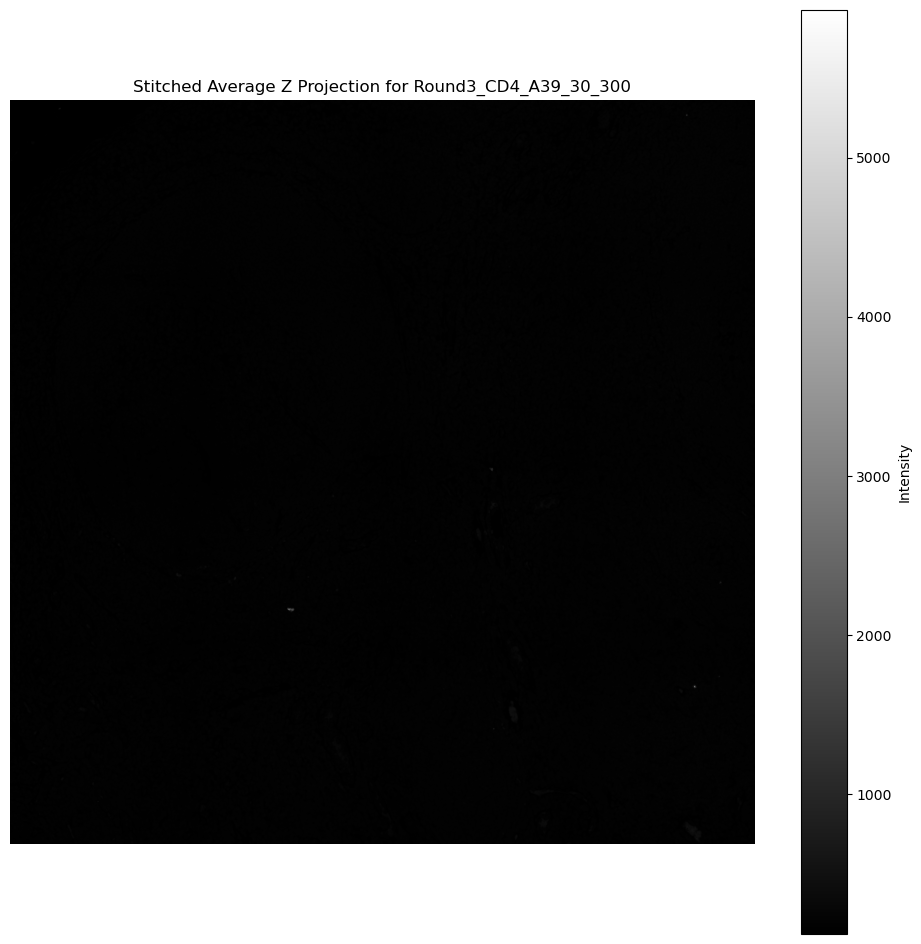

Stitching process completed for Round3_CD4_A39_30_300.
--- Finished Round 9 of 15: Round3_CD4_A39_30_300 ---


--- Processing Round 10 of 15: Round4_CD20_A3_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round4_CD20_A3_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round4_CD20_A3_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of shape 

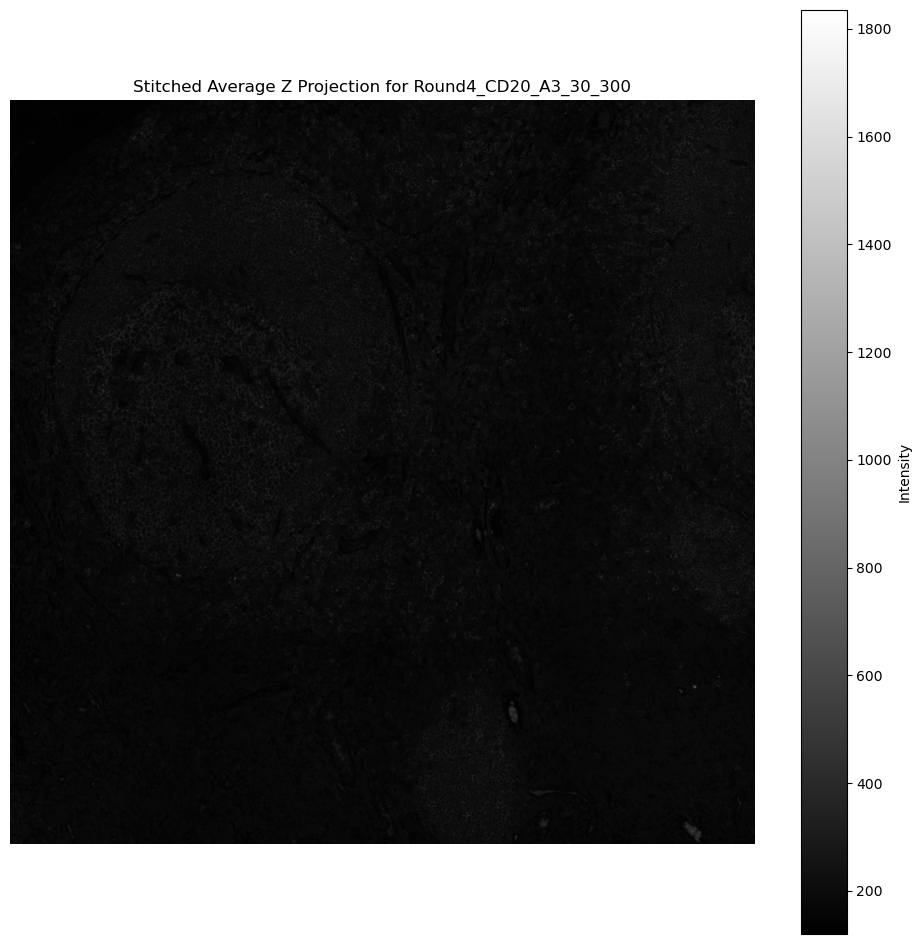

Stitching process completed for Round4_CD20_A3_30_300.
--- Finished Round 10 of 15: Round4_CD20_A3_30_300 ---


--- Processing Round 11 of 15: Round5_Tom20_A20_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round5_Tom20_A20_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round5_Tom20_A20_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of

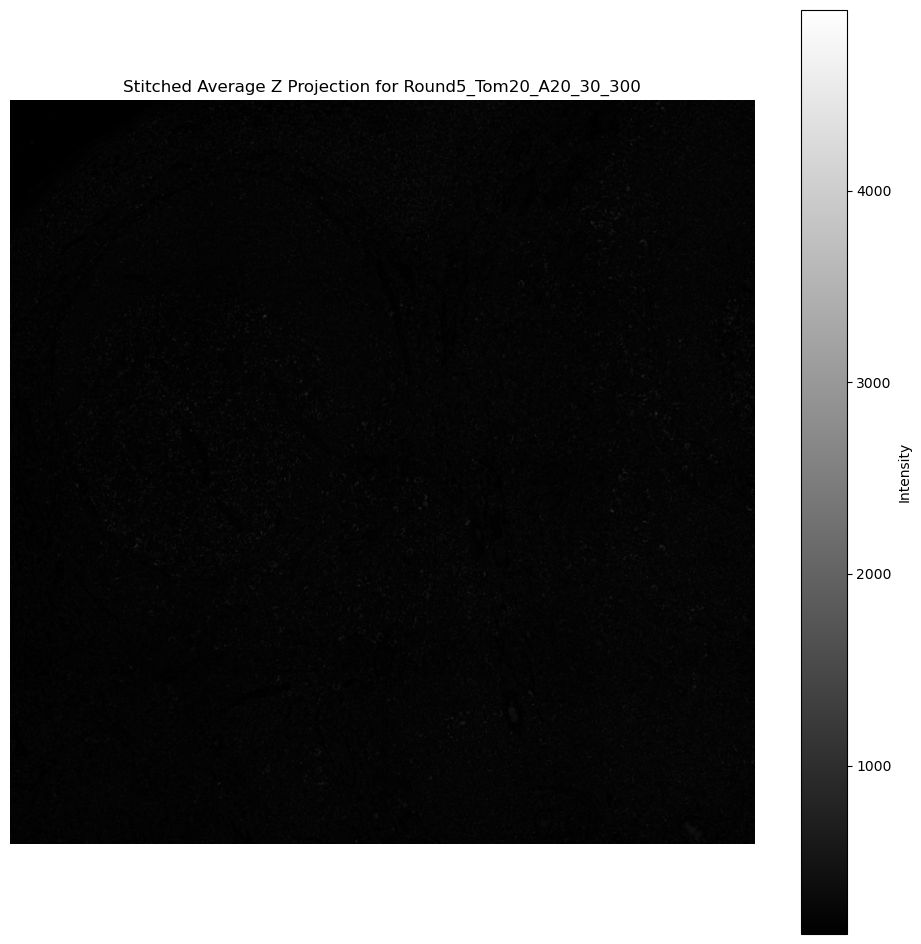

Stitching process completed for Round5_Tom20_A20_30_300.
--- Finished Round 11 of 15: Round5_Tom20_A20_30_300 ---


--- Processing Round 12 of 15: Round6_CD63_A10_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round6_CD63_A10_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round6_CD63_A10_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas o

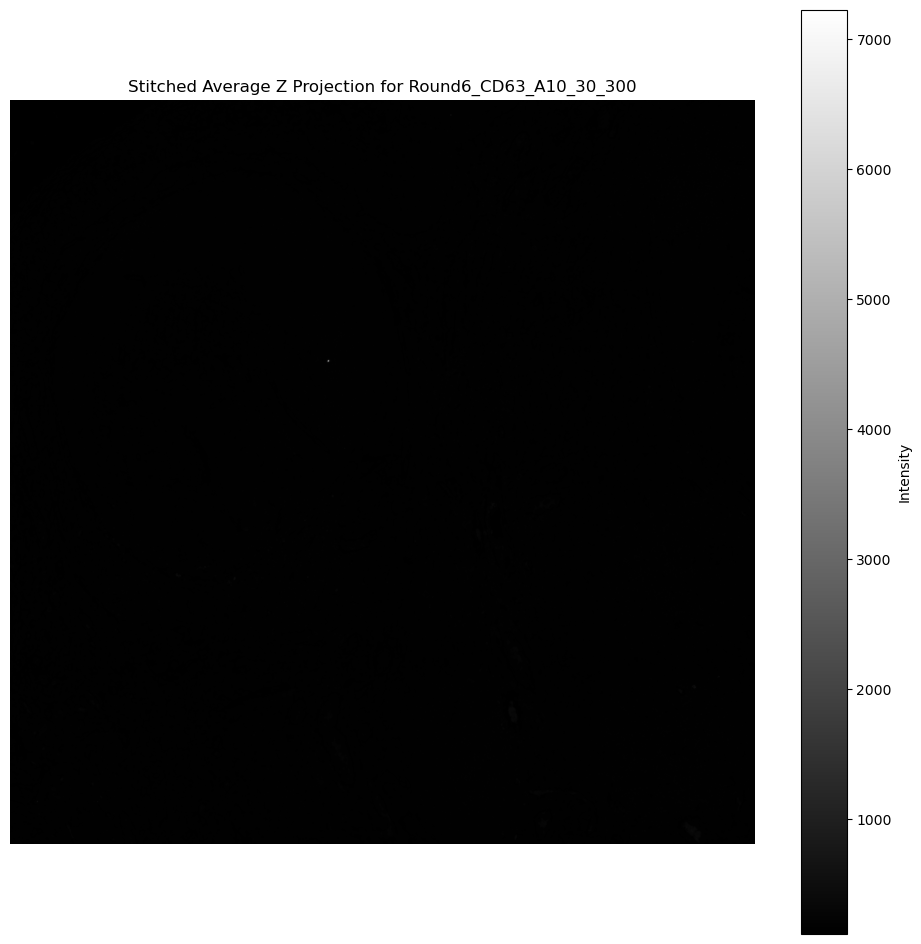

Stitching process completed for Round6_CD63_A10_30_300.
--- Finished Round 12 of 15: Round6_CD63_A10_30_300 ---


--- Processing Round 13 of 15: Round7_CD19_A36_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round7_CD19_A36_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round7_CD19_A36_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canvas of 

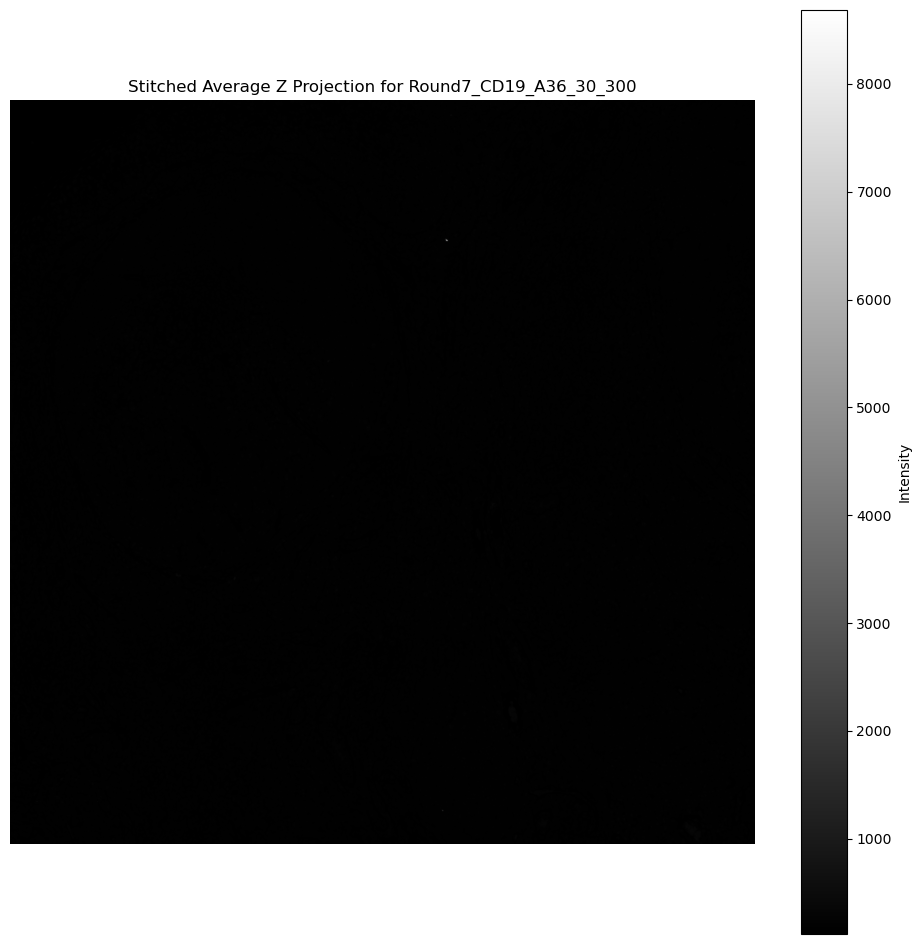

Stitching process completed for Round7_CD19_A36_30_300.
--- Finished Round 13 of 15: Round7_CD19_A36_30_300 ---


--- Processing Round 14 of 15: Round8_Vimentin_A5_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round8_Vimentin_A5_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round8_Vimentin_A5_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count c

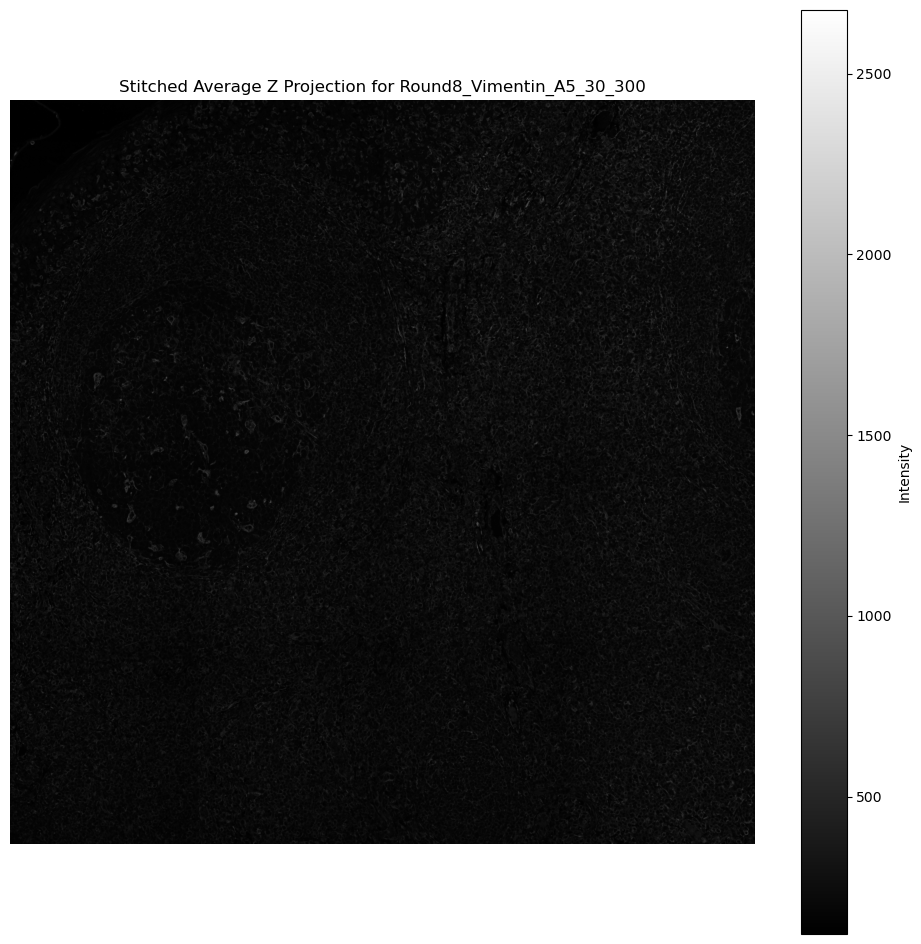

Stitching process completed for Round8_Vimentin_A5_30_300.
--- Finished Round 14 of 15: Round8_Vimentin_A5_30_300 ---


--- Processing Round 15 of 15: Round9_Ki67_A15_30_300 ---
Attempting to parse XML: E:\20250404_DNA_PAINT_12 targets_ON testing\Round9_Ki67_A15_30_300_FusionStitcher_pair.xml
XML parsing successful. Found 16 tiles.
Attempting to parse TXT: E:\20250404_DNA_PAINT_12 targets_ON testing\Round9_Ki67_A15_30_300_metadata.txt
Found tile_pixel_width: 2048
Found tile_pixel_height: 2046
TXT parsing complete.
Derived effective_pixel_width_um: 0.1507
Derived effective_pixel_height_um: 0.1507

--- Metadata Summary ---
Number of tiles: 16
Tile pixel dimensions: 2048x2046
Effective physical pixel size: 0.1507x0.1507 µm
------------------------

Global physical bounds (µm):
  X: [-2516.26, -1290.64]
  Y: [-9792.71, -8568.29]
Calculated canvas dimensions: 8131x8123 pixels
Initialized stitched image sum canvas of shape (8123, 8131) with dtype float32
Initialized stitched image count canv

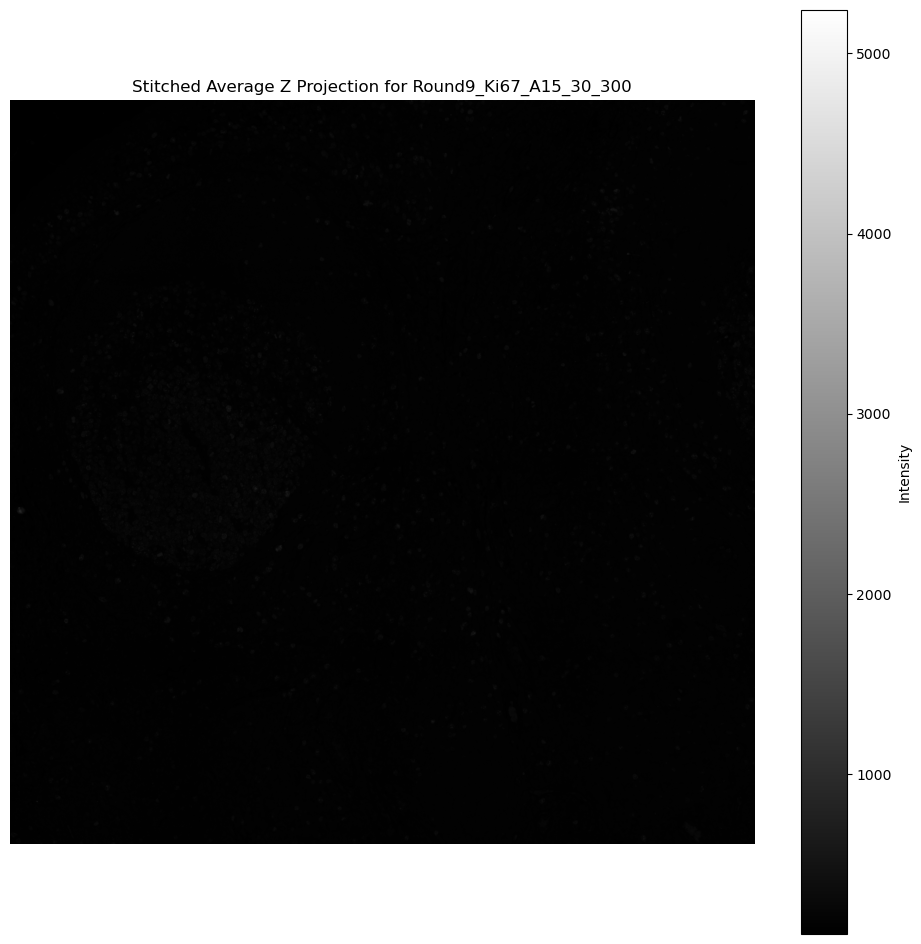

Stitching process completed for Round9_Ki67_A15_30_300.
--- Finished Round 15 of 15: Round9_Ki67_A15_30_300 ---



In [2]:
data_path = r"E:\20250404_DNA_PAINT_12 targets_ON testing"

# Define the subfolder for analysis results
analysis_results_subfolder = "analysis_results_avgIntAtOverlap"
output_dir = os.path.join(data_path, analysis_results_subfolder)

# Create the analysis results subfolder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Ensured output directory exists: {output_dir}")

# Discover round names based on file pattern: any file ending with _FusionStitcher.ims
rounds_to_process = []
# Regex to match anything before "_FusionStitcher.ims"
round_file_pattern = re.compile(r"(.*)_FusionStitcher\.ims") 

# List files directly within data_path
for item in os.listdir(data_path):
    # Check if the item is a file and matches the round file pattern
    match = round_file_pattern.match(item)
    if os.path.isfile(os.path.join(data_path, item)) and match:
        round_name = match.group(1) # Extract the part before "_FusionStitcher.ims"
        rounds_to_process.append(round_name)

if not rounds_to_process:
    print(f"No .ims files matching pattern '*_FusionStitcher.ims' found in {data_path}. Please check your data structure.")
else:
    # Use a set to ensure unique round names, then convert back to list and sort
    rounds_to_process = sorted(list(set(rounds_to_process)))
    total_rounds = len(rounds_to_process) # Get total number of rounds

    print(f"Found {total_rounds} unique rounds to process: {', '.join(rounds_to_process)}")

    for round_idx, current_round_name in enumerate(rounds_to_process): # Use enumerate for index
        current_round_num = round_idx + 1 # 1-based indexing for display
        print(f"\n--- Processing Round {current_round_num} of {total_rounds}: {current_round_name} ---")
        
        # Output filename now includes the analysis_results subfolder
        output_stitched_filename = os.path.join(output_dir, f"{current_round_name}_Stitched_MIP.tif")

        # 1. Parse metadata for the current round
        stitching_metadata = parse_stitching_metadata(current_round_name, data_path)

        if stitching_metadata:
            print("\n--- Metadata Summary ---")
            print(f"Number of tiles: {len(stitching_metadata['tile_info'])}")
            print(f"Tile pixel dimensions: {stitching_metadata['tile_pixel_width']}x{stitching_metadata['tile_pixel_height']}")
            print(f"Effective physical pixel size: {stitching_metadata['effective_pixel_width_um']:.4f}x{stitching_metadata['effective_pixel_height_um']:.4f} µm")
            print("------------------------")

            # 2. Stitch the images for the current round
            stitched_result = stitch_max_z_projection(
                stitching_metadata,
                output_stitched_filename,
                current_round_name,
                current_round_num, # Pass current round number
                total_rounds       # Pass total rounds
            )

            if stitched_result is not None:
                print(f"Stitching process completed for {current_round_name}.")
                if np.max(stitched_result) == 0:
                    print("WARNING: The final stitched image contains only zero values.")
            else:
                print(f"Stitching process failed for {current_round_name}.")
        else:
            print(f"Failed to parse stitching metadata for {current_round_name}, cannot proceed with stitching.")
        print(f"--- Finished Round {current_round_num} of {total_rounds}: {current_round_name} ---\n")

In [1]:
import os
import re
from aicsimageio import AICSImage
import imageio.v3 as iio
import numpy as np

# --- Configuration ---
data_path = r"E:\20250404_DNA_PAINT_12 targets_ON testing"
output_subfolder_name = "analysis_results_FusionStitcher"
output_dir = os.path.join(data_path, output_subfolder_name)

# Create the output subfolder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Ensured output directory exists: {output_dir}")

# Regex to find any file ending with _FusionStitcher.ims
fusion_stitcher_file_pattern = re.compile(r"(.*_FusionStitcher)\.ims")

# List to store paths of found .ims files
ims_files_to_process = []

# Discover all *FusionStitcher.ims files
for item in os.listdir(data_path):
    match = fusion_stitcher_file_pattern.match(item)
    if os.path.isfile(os.path.join(data_path, item)) and match:
        ims_files_to_process.append(os.path.join(data_path, item))

if not ims_files_to_process:
    print(f"No '*_FusionStitcher.ims' files found in {data_path}.")
else:
    print(f"Found {len(ims_files_to_process)} '*_FusionStitcher.ims' files to convert.")
    
    total_files = len(ims_files_to_process)
    for file_idx, ims_filepath in enumerate(ims_files_to_process):
        current_file_num = file_idx + 1
        base_filename = os.path.basename(ims_filepath)
        print(f"\nProcessing file {current_file_num} of {total_files}: {base_filename}")

        try:
            # Load the .ims file
            img = AICSImage(ims_filepath)

            # Determine output TIFF filename
            # Replace .ims extension with .tif
            output_tif_filename = base_filename.replace(".ims", "_MIP.tif") # Added _MIP to filename
            output_tif_filepath = os.path.join(output_dir, output_tif_filename)

            # Extract image data. Assuming we want the first channel, first time point, first scene.
            # You might need to adjust C, T, S if your files have multiple channels/timepoints/scenes
            # and you want to extract specific ones.
            image_data_zyx = img.get_image_data("ZYX", C=0, T=0, S=0)

            # --- Perform Max Z Projection ---
            if image_data_zyx.shape[0] > 1: # Check if there's more than one Z-slice
                projected_image = np.max(image_data_zyx, axis=0)
            else:
                projected_image = image_data_zyx[0, :, :] # If only one Z-slice, just take that slice

            # Save as TIFF
            iio.imwrite(output_tif_filepath, projected_image)
            print(f"Successfully extracted and saved '{output_tif_filename}' to '{output_dir}'")

        except Exception as e:
            print(f"ERROR processing '{base_filename}': {e}")
            continue

    print("\nFinished extracting all '*_FusionStitcher.ims' files to TIFF (Max Intensity Projection).")

Ensured output directory exists: E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_FusionStitcher
Found 15 '*_FusionStitcher.ims' files to convert.

Processing file 1 of 15: Round0_30_300_1_FusionStitcher.ims
Successfully extracted and saved 'Round0_30_300_1_FusionStitcher_MIP.tif' to 'E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_FusionStitcher'

Processing file 2 of 15: Round0_30_300_FusionStitcher.ims
Successfully extracted and saved 'Round0_30_300_FusionStitcher_MIP.tif' to 'E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_FusionStitcher'

Processing file 3 of 15: Round10_CD45_A27_30_300_FusionStitcher.ims
Successfully extracted and saved 'Round10_CD45_A27_30_300_FusionStitcher_MIP.tif' to 'E:\20250404_DNA_PAINT_12 targets_ON testing\analysis_results_FusionStitcher'

Processing file 4 of 15: Round11_SMA_A25_30_300_FusionStitcher.ims
Successfully extracted and saved 'Round11_SMA_A25_30_300_FusionStitcher_MIP.tif' to 'E:\20250404_DNA_PAINT_12 tar